In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
df=pd.read_csv(r"C:/Users/HP/Downloads/Customer_Churn.csv")
customer_churn=df.copy()
customer_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
customer_churn.shape
#checking the dataset shape 

(7043, 21)

In [4]:
customer_churn.dtypes
#checking the data types of the features

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
customer_churn.isna().sum()
#verifying if we have missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
customer_churn.duplicated().sum()
#verifying if we have duplicate rows

np.int64(0)

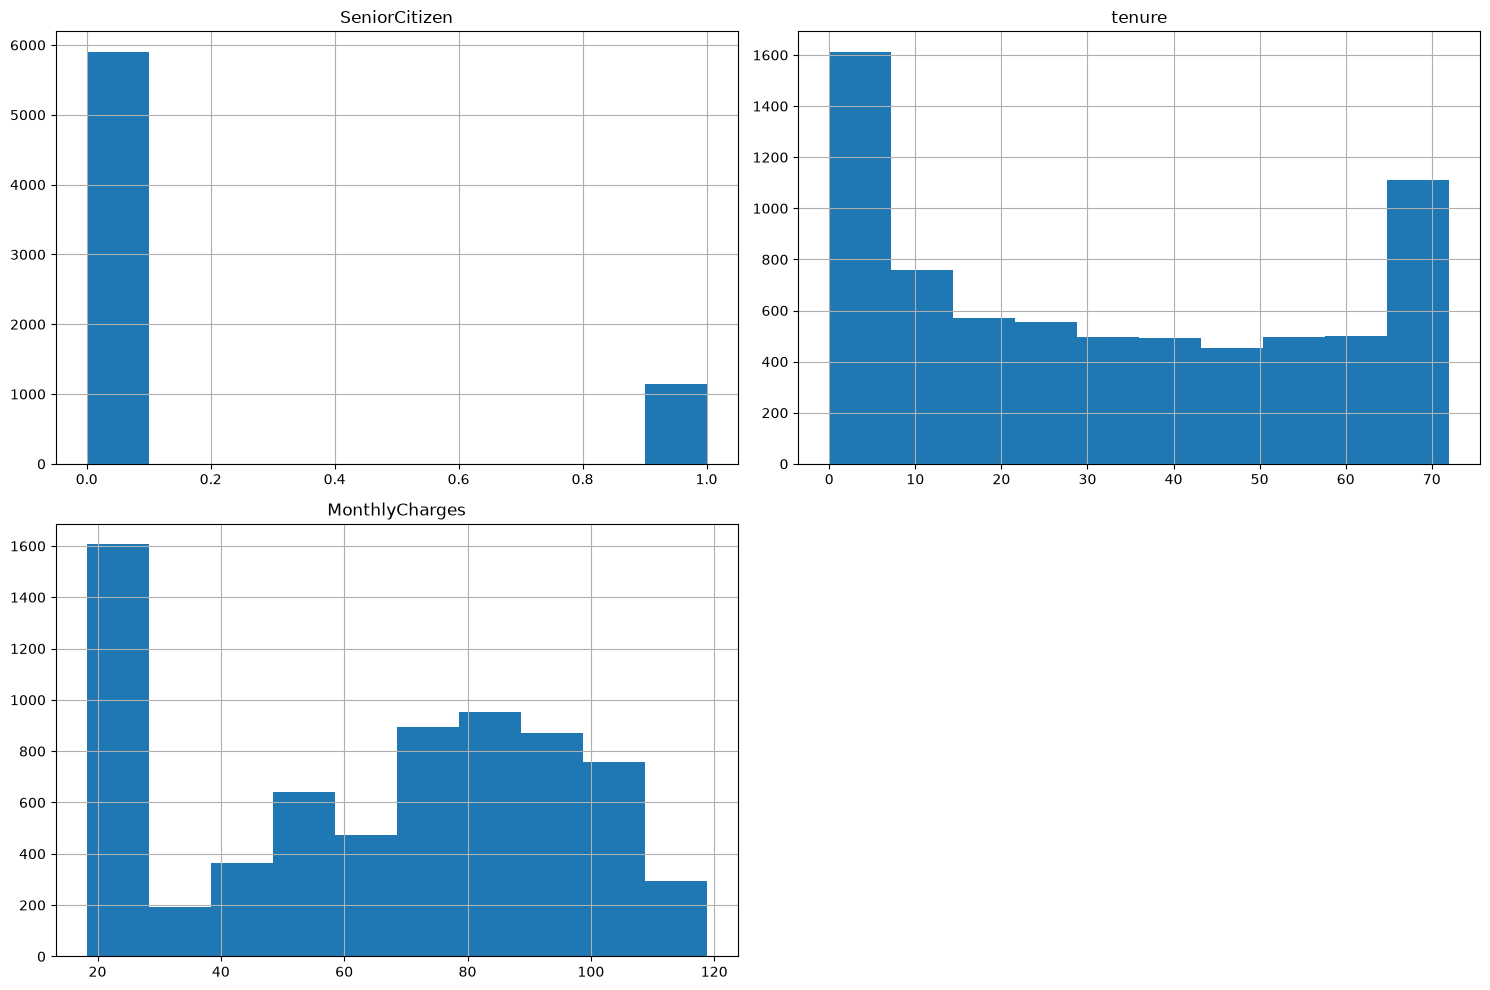

In [7]:
#drawing multiple histograms for numerical features
numerical_cols = customer_churn.select_dtypes(include=np.number).columns

customer_churn[numerical_cols].hist(figsize=(15,10))

plt.tight_layout()

plt.show()

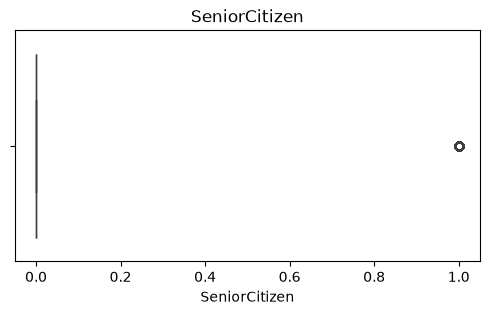

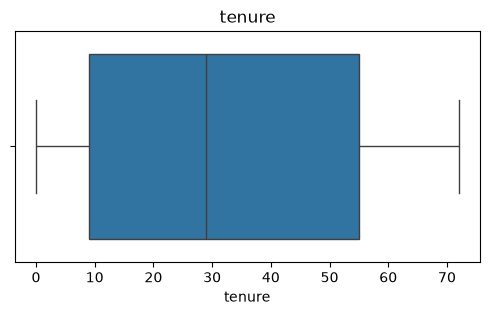

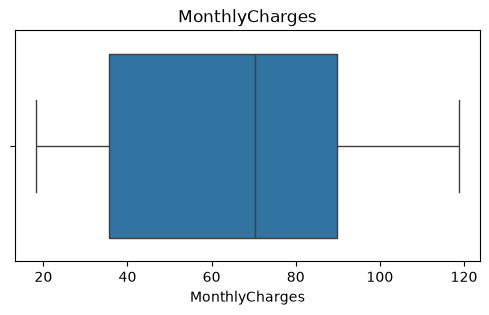

In [8]:
import seaborn as sns
#drawing multiple boxplots for numerical features
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_30260\4115533727.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = customer_churn.select_dtypes(include="object").columns


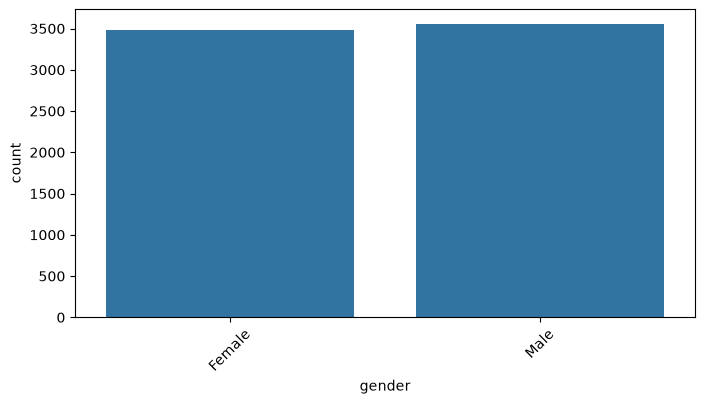

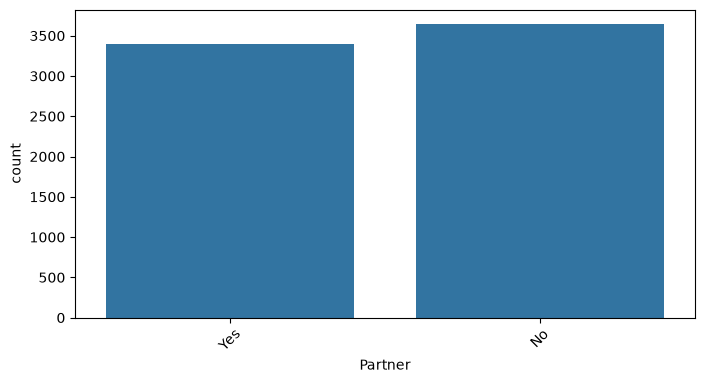

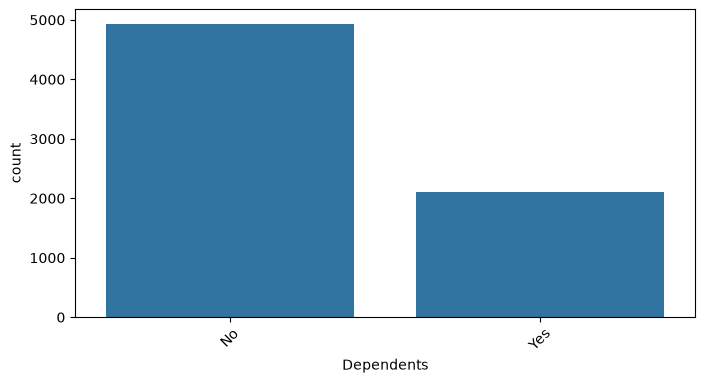

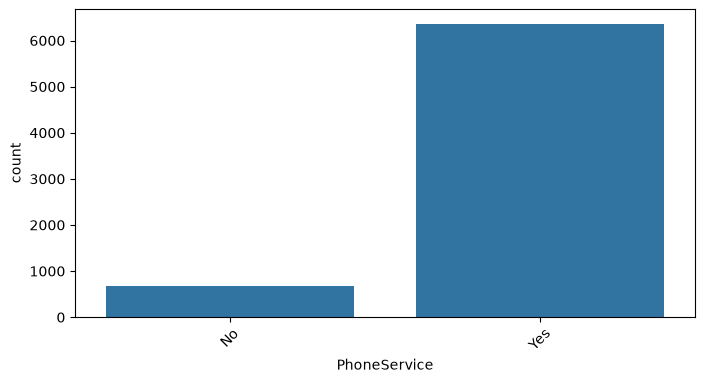

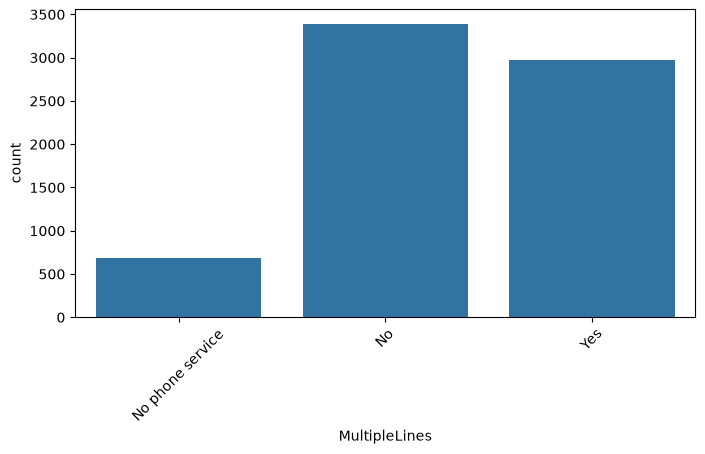

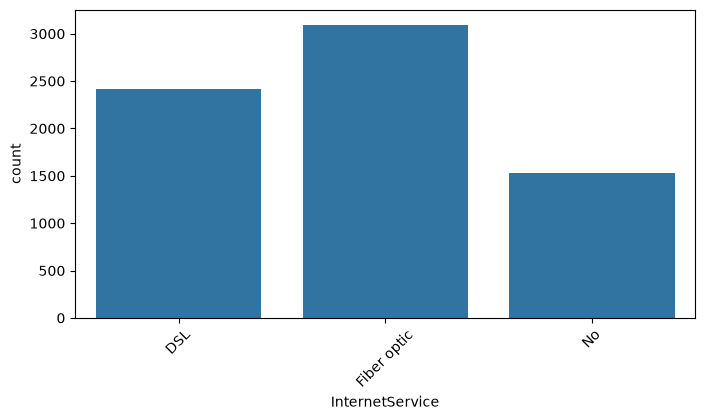

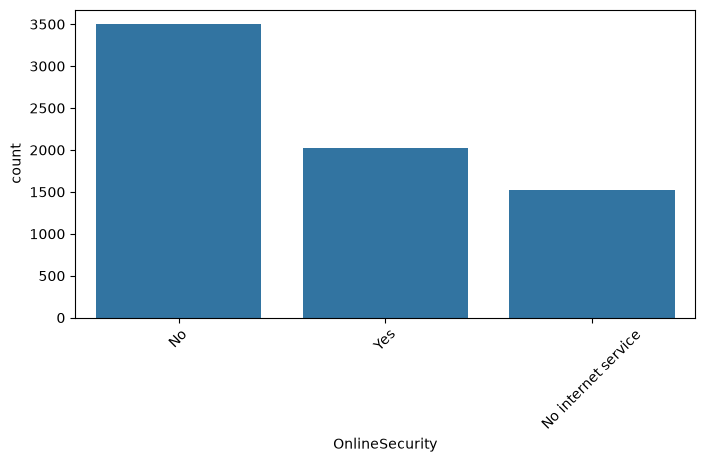

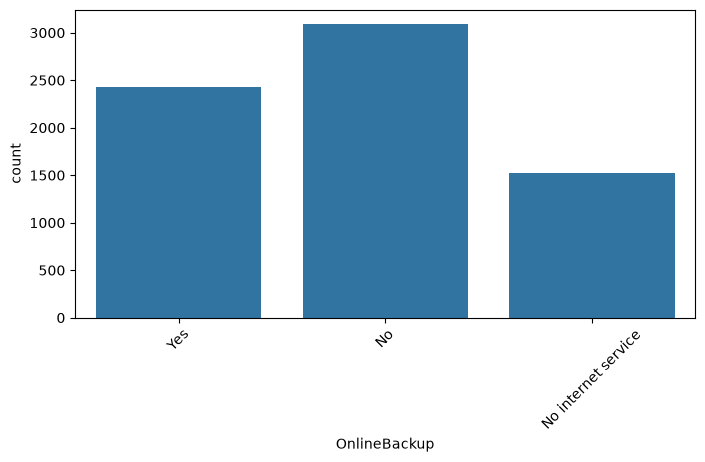

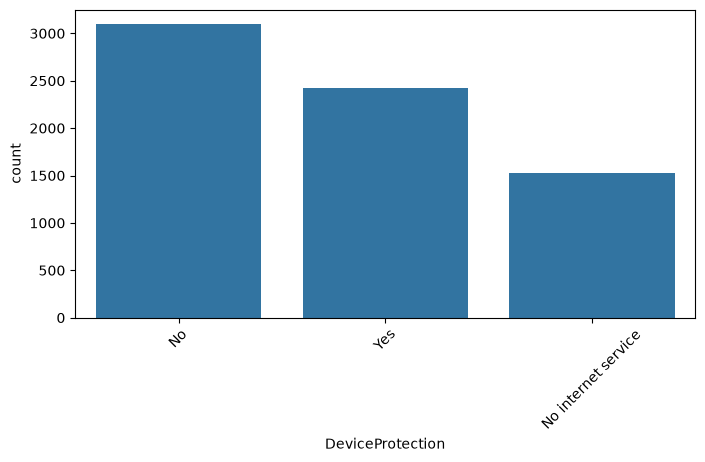

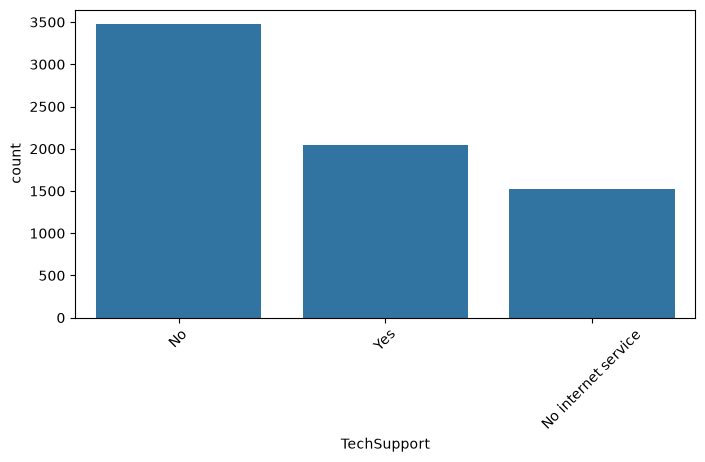

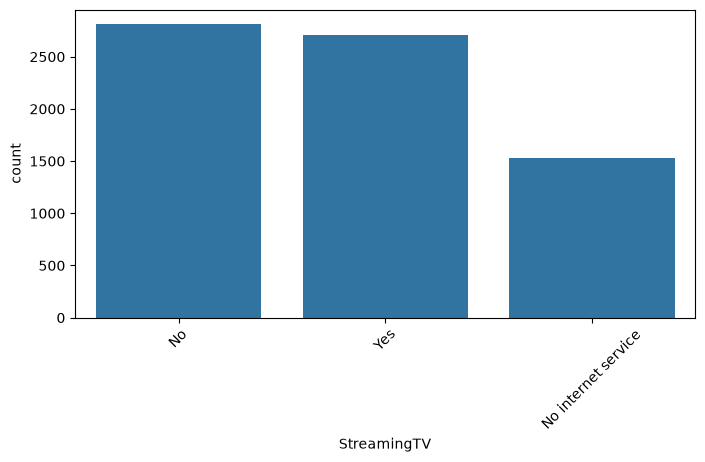

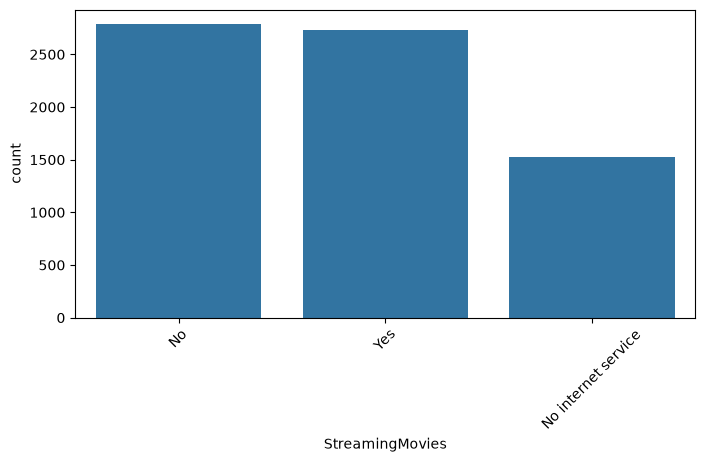

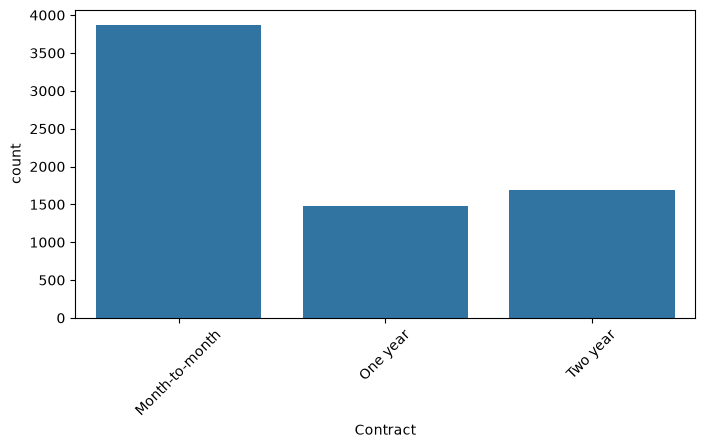

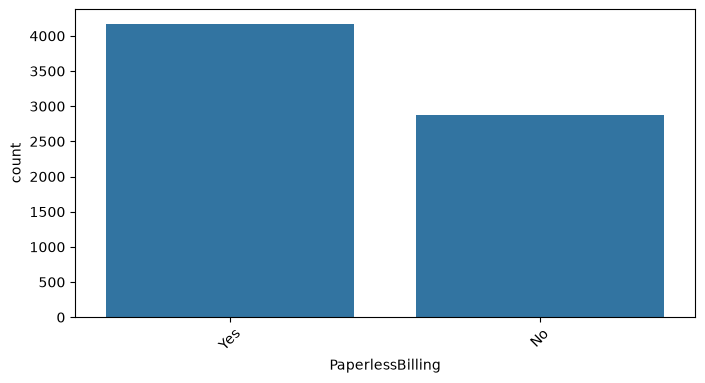

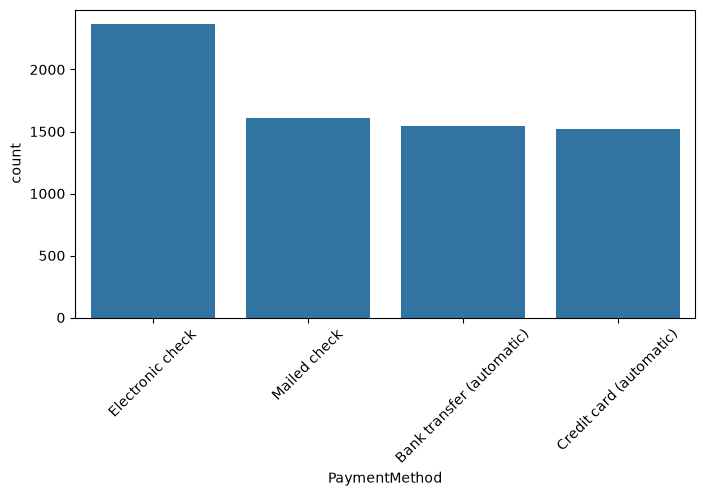

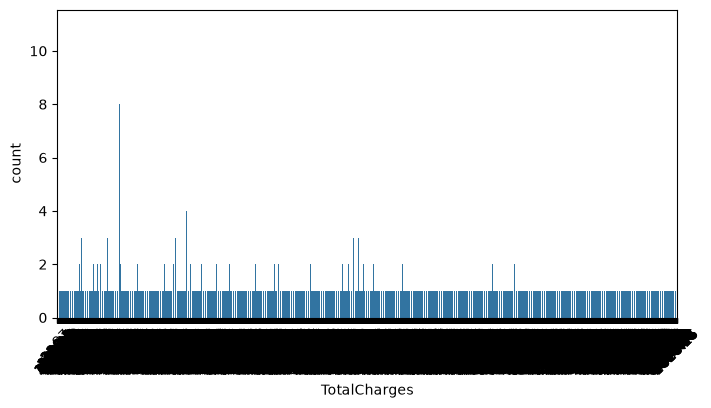

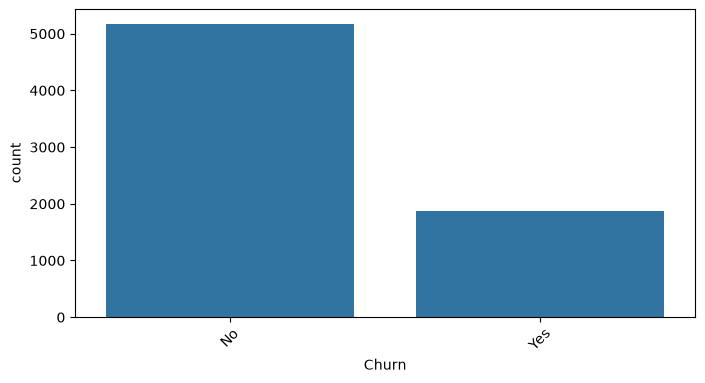

In [9]:
categorical_cols = customer_churn.select_dtypes(include="object").columns
categorical_cols=categorical_cols.drop("customerID")
#drawing multiple plots for categorical features
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=customer_churn)
    plt.xticks(rotation=45)
    plt.show()

In [10]:
customer_churn.describe()
#making a summary for the dataset to our numerical features

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
customer_churn["Churn"].unique()
#finding the unique values of Churn

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

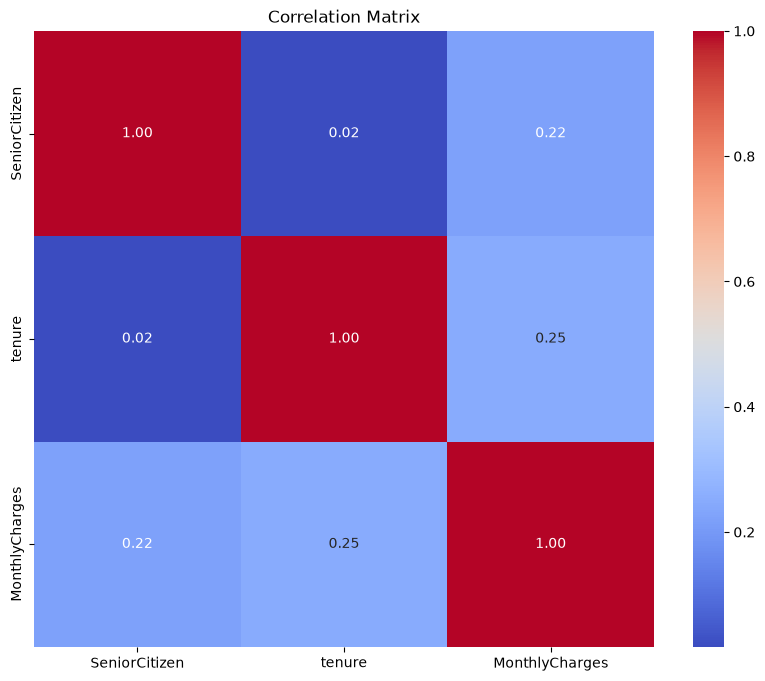

In [12]:
corr = customer_churn.corr(numeric_only=True)
#drawing the correlation matrix of the numerical features of the dataset
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

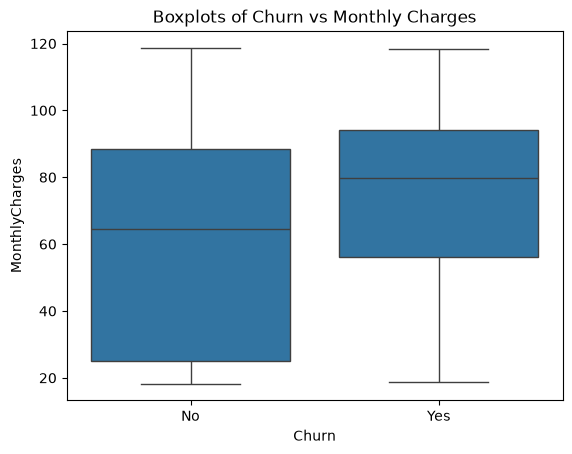

In [13]:
sns.boxplot(x="Churn",
            y="MonthlyCharges",
            data=customer_churn)
plt.title("Boxplots of Churn vs Monthly Charges")
plt.show()

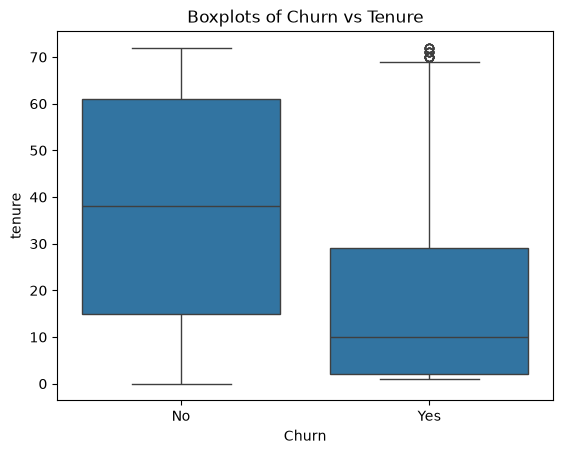

In [14]:
sns.boxplot(x="Churn",
            y="tenure",
            data=customer_churn)
plt.title("Boxplots of Churn vs Tenure")
plt.show()

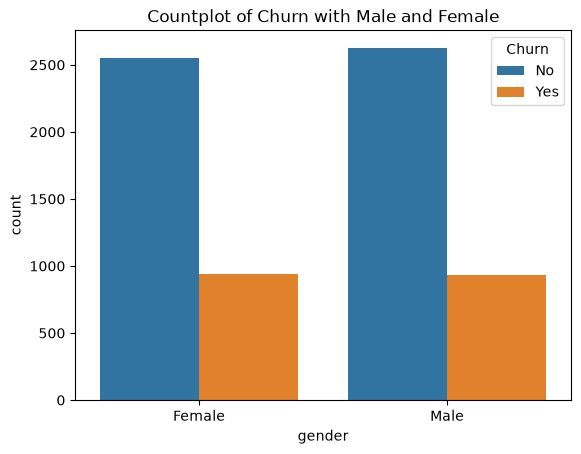

In [15]:
sns.countplot(x="gender",
              hue="Churn",
              data=customer_churn)
plt.title("Countplot of Churn with Male and Female")
plt.show()

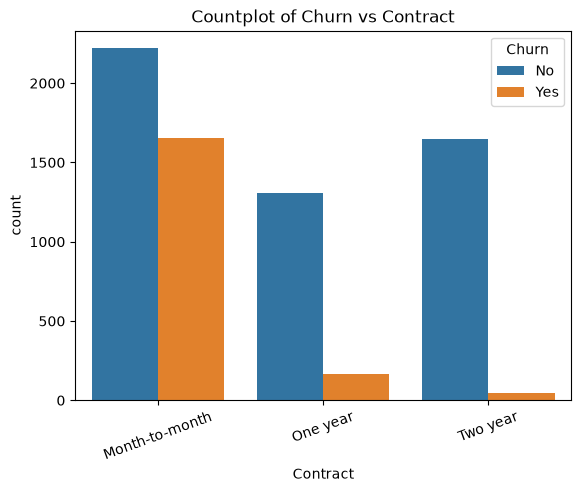

In [16]:
sns.countplot(x="Contract",
              hue="Churn",
              data=customer_churn)

plt.xticks(rotation=20)
plt.title("Countplot of Churn vs Contract")
plt.show()

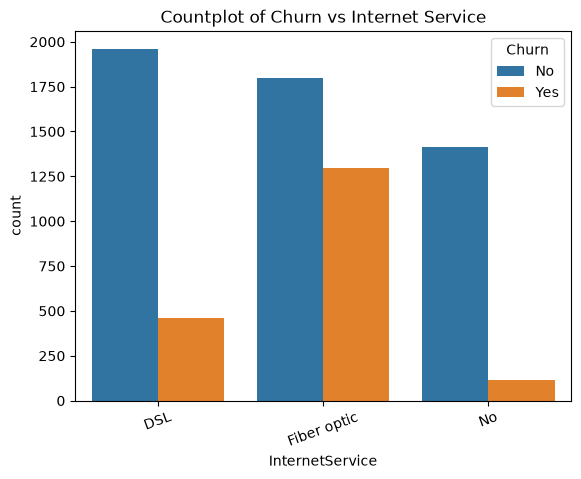

In [17]:
sns.countplot(x="InternetService",
              hue="Churn",
              data=customer_churn)

plt.xticks(rotation=20)
plt.title("Countplot of Churn vs Internet Service")
plt.show()

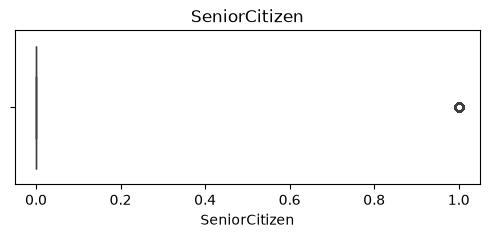

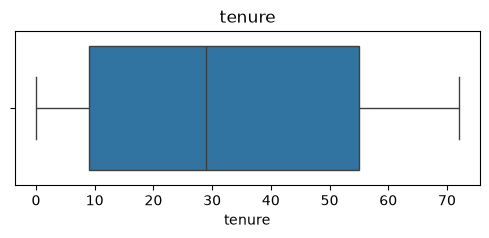

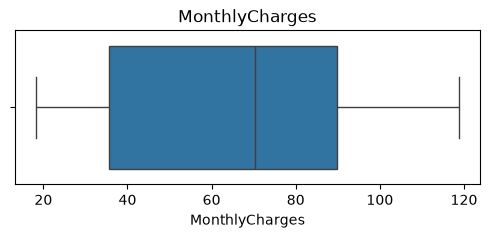

In [18]:
#detecting any available outlier
for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=customer_churn[col])
    plt.title(col)
    plt.show()

In [19]:
#converting TotalCharges from string to numeric
customer_churn["TotalCharges"]=pd.to_numeric(customer_churn["TotalCharges"],errors="coerce")

In [20]:
#separating features from target
X=customer_churn.drop(["customerID","MonthlyCharges","Churn","TotalCharges"],axis=1)
y=customer_churn["MonthlyCharges"]

In [21]:
#checking the features of X
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [22]:
#building the preprocessing pipeline 

#identifying numerical and categorical features
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

#import necessary libraries for preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

#creating the numerical pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

#creating the categorical pipepline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#combining 
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

C:\Users\HP\AppData\Local\Temp\ipykernel_30260\331645386.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [23]:
np.random.seed(42)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [24]:
#building the Linear Regression model
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['gender','SeniorCitizen','Partner',...,'Contract','PaperlessBilling', 'PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This s

In [25]:
#making predictions
y_pred = linear_pipeline.predict(X_test)
y_pred

array([24.95966268, 24.98735779, 19.92427981, ..., 19.95950489,
       44.9247107 , 29.94193257], shape=(1409,))

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#calculating the metrics for this model like MSE,RMSE and R2
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MAE : 0.7892749564822916
RMSE: 1.0512898797235475
R² : 0.998779278341754


In [27]:
# Hyperparameters for Linear Regression
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False]
}

# Grid Search
lin_grid = GridSearchCV(
    estimator=linear_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Train
lin_grid.fit(X_train, y_train)

print("Best Parameters:", lin_grid.best_params_)
print("Best CV R²:", lin_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'model__fit_intercept': False, 'model__positive': True}
Best CV R²: 0.9988448666266674


In [28]:
#building the Decision Tree Regression model
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

pred_tree = tree_pipeline.predict(X_test)

print("R² :", r2_score(y_test, pred_tree))

R² : 0.9972957120829044


In [31]:
#Hyperparameters for Decision Tree Regressor
param_grid = {
    "model__criterion": ["squared_error", "absolute_error"],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [None, "sqrt", "log2"]
}

# Grid Search
tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

tree_grid.fit(X_train,y_train)

print("Best Parameters:", tree_grid.best_params_)
print("Best CV R²:", tree_grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'model__criterion': 'squared_error', 'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best CV R²: 0.9970598606776268


In [32]:
#building the Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

pred_rf = rf_pipeline.predict(X_test)

print("R² :", r2_score(y_test, pred_rf))

R² : 0.9981625875831159


In [33]:
#Lets make a hyperparameter tuning with GridSearchCV for Random Forest Regressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Random Forest MAE: 0.9062193152530809
Random Forest RMSE: 1.244230528177577
Random Forest R²: 0.9982900894637428


In [34]:
print(f"The best parameters for Random Forest cross validation are : {rf_grid.best_params_}")
print(f"The best score for Random Forest cross validation is : {rf_grid.best_score_}")

The best parameters for Random Forest cross validation are : {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
The best score for Random Forest cross validation is : 0.9979197489329372


In [35]:
#let's try Ridge Regression for our dataset
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])
ridge_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['gender','SeniorCitizen','Partner',...,'Contract','PaperlessBilling', 'PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This s

In [36]:
ridge_pipeline.score(X_test,y_test)

0.9987788111084025

In [37]:
y_pred_ridge = ridge_pipeline.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R²:", r2_ridge)

Ridge MAE: 0.7893271038896695
Ridge RMSE: 1.0514910519964247
Ridge R²: 0.9987788111084025


In [38]:
#Hyperparameters for Ridge Regression
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best parameters:", ridge_grid.best_params_)
print("Best CV R²:", ridge_grid.best_score_)

Best parameters: {'model__alpha': 0.1}
Best CV R²: 0.998842761749042


In [39]:
best_ridge = ridge_grid.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Final Ridge MAE:", mae_ridge)
print("Final Ridge RMSE:", rmse_ridge)
print("Final Ridge R²:", r2_ridge)

Final Ridge MAE: 0.7892731765144448
Final Ridge RMSE: 1.0513075031165768
Final Ridge R²: 0.9987792374140549


In [40]:
best_ridge = ridge_grid.best_estimator_
best_ridge

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['gender','SeniorCitizen','Partner',...,'Contract','PaperlessBilling', 'PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This s

In [41]:
#saving the best regression model which is the Ridge Regression model here as a pickle file
import pickle
from pickle import load,dump

with open("regression_model.pkl", "wb") as file:
    pickle.dump(best_ridge, file)

#load the file
with open("regression_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)    